**Evaluating Machine Learning Approaches for Predicting Liver Cancer Outcomes Post-COVID-19**

In [43]:
# import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    confusion_matrix,
)

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier
from sklearn.neural_network import MLPClassifier

import warnings
warnings.filterwarnings('ignore')

#### **Load data and preprocess**
- Kaggle link: [Liver Caner Dataset on Kaggle](https://www.kaggle.com/datasets/fedesoriano/covid19-effect-on-liver-cancer-prediction-dataset)

In [44]:
# load dataset
liver_cancer_df = pd.read_csv('../data/covid_liver.csv', encoding='cp1252')
print("Shape of the dataset:", liver_cancer_df.shape)
liver_cancer_df.head()

Shape of the dataset: (450, 27)


,Cancer,Year,Month,Bleed,Mode_Presentation,Age,Gender,Etiology,Cirrhosis,Size,HCC_TNM_Stage,HCC_BCLC_Stage,ICC_TNM_Stage,Treatment_grps,Survival_fromMDM,Alive_Dead,Type_of_incidental_finding,Surveillance_programme,Surveillance_effectiveness,Mode_of_surveillance_detection,Time_diagnosis_1st_Tx,Date_incident_surveillance_scan,PS,Time_MDM_1st_treatment,Time_decisiontotreat_1st_treatment,Prev_known_cirrhosis,Months_from_last_surveillance
0,Y,Prepandemic,1,N,Surveillance,68,M,NAFLD,Y,22.0,II,A,NaN,Ablation,32.73,Alive,NaN,Y,Consistent,US,0.47,NaN,0.0,0.7,NaN,Y,7.333333
1,Y,Prepandemic,1,N,Surveillance,70,M,ARLD,Y,40.0,I,D,NaN,Supportive care,3.03,Dead,NaN,Y,Consistent,US,NaN,NaN,2.0,NaN,NaN,Y,4.033333
2,Y,Prepandemic,1,N,Surveillance,64,M,ARLD,Y,52.0,IV,B,NaN,Medical,14.97,Dead,NaN,Y,Consistent,US,NaN,NaN,0.0,NaN,NaN,Y,5.900000
3,Y,Prepandemic,1,N,Incidental,73,M,ARLD,Y,80.0,IV,C,NaN,Supportive care,1.40,Dead,Secondary care—acute,N,NaN,NaN,NaN,NaN,2.0,NaN,NaN,Y,NaN
4,Y,Prepandemic,1,N,Incidental,66,F,ARLD,Y,60.0,I,0,NaN,Supportive care,32.50,Alive,Secondary care—acute,N,NaN,NaN,NaN,NaN,0.0,NaN,NaN,Y,NaN


In [45]:
# column names in the dataset
liver_cancer_df.columns

Index(['Cancer', 'Year', 'Month', 'Bleed', 'Mode_Presentation', 'Age',
       'Gender', 'Etiology', 'Cirrhosis', 'Size', 'HCC_TNM_Stage',
       'HCC_BCLC_Stage', 'ICC_TNM_Stage', 'Treatment_grps', 'Survival_fromMDM',
       'Alive_Dead', 'Type_of_incidental_finding', 'Surveillance_programme',
       'Surveillance_effectiveness', 'Mode_of_surveillance_detection',
       'Time_diagnosis_1st_Tx', 'Date_incident_surveillance_scan', 'PS',
       'Time_MDM_1st_treatment', 'Time_decisiontotreat_1st_treatment',
       'Prev_known_cirrhosis', 'Months_from_last_surveillance'],
      dtype='object')

In [46]:
# target column
target_column = 'Cancer'

y = liver_cancer_df[target_column]
y.value_counts()

Cancer
Y    310
N    140
Name: count, dtype: int64

In [47]:
# Convert target to binary (1 = cancer, 0 = no cancer)
y = y.replace({'Y': 1, 'N': 0}).astype(int)

In [48]:
# feature columns
X = liver_cancer_df.drop(columns=[target_column])
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 26 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Year                                450 non-null    object 
 1   Month                               450 non-null    int64  
 2   Bleed                               310 non-null    object 
 3   Mode_Presentation                   450 non-null    object 
 4   Age                                 450 non-null    int64  
 5   Gender                              450 non-null    object 
 6   Etiology                            311 non-null    object 
 7   Cirrhosis                           311 non-null    object 
 8   Size                                400 non-null    float64
 9   HCC_TNM_Stage                       311 non-null    object 
 10  HCC_BCLC_Stage                      311 non-null    object 
 11  ICC_TNM_Stage                       139 non-n

In [49]:
# drop numeric ID columns if any
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

In [50]:
# For numeric variables fill with median
X[num_cols] = X[num_cols].apply(lambda col: col.fillna(col.median()))

# For categorical variables fill with mode (most frequent)
for c in cat_cols:
    X[c] = X[c].fillna(X[c].mode()[0] if not X[c].mode().empty else "Unknown")

In [51]:
# one hot encode categorical columns
X = pd.get_dummies(X, drop_first=True)

In [52]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [53]:
# Scaler for numeric features
scaler = ColumnTransformer([
    ("num", StandardScaler(), X.columns.tolist())
], remainder="drop")

#### **Define Models**

In [54]:
# define models to train
models = {
    "SVC (RBF)": Pipeline([
        ("pre", scaler),
        ("clf", SVC(kernel="rbf", probability=True, C=2.0, gamma="scale", random_state=0))
    ]),
    "GaussianNB": Pipeline([
        ("clf", GaussianNB())
    ]),
    "SGD (logistic)": Pipeline([
        ("pre", scaler),
        ("clf", SGDClassifier(loss="log_loss", penalty="elasticnet",
                              alpha=1e-4, l1_ratio=0.15,
                              early_stopping=True, random_state=0))
    ]),
    "MLP (64,32)": Pipeline([
        ("pre", scaler),
        ("clf", MLPClassifier(hidden_layer_sizes=(64, 32),
                              activation="relu", alpha=1e-4,
                              learning_rate_init=1e-3,
                              max_iter=400, early_stopping=True,
                              random_state=0))
    ]),
}

#### **Metrics Function**

In [55]:
def compute_binary_metrics_extended(y_true, y_pred, y_proba_pos):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    npv = tn / (tn + fn) if (tn + fn) else 0.0
    f1 = f1_score(y_true, y_pred, zero_division=0)
    f05 = fbeta_score(y_true, y_pred, beta=0.5, zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2.0, zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_proba_pos)
    pr = average_precision_score(y_true, y_proba_pos)
    ll = log_loss(y_true, np.vstack([1 - y_proba_pos, y_proba_pos]).T, labels=[0, 1])
    brier = brier_score_loss(y_true, y_proba_pos)
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    fnr = fn / (fn + tp) if (fn + tp) else 0.0

    return {
        "Accuracy": acc,
        "Precision (PPV)": prec,
        "Recall (Sensitivity/TPR)": rec,
        "Specificity (TNR)": spec,
        "NPV": npv,
        "F1": f1,
        "F0.5": f05,
        "F2": f2,
        "Balanced Accuracy": bal_acc,
        "MCC": mcc,
        "Cohen Kappa": kappa,
        "ROC AUC": roc,
        "PR AUC (AP)": pr,
        "Log Loss": ll,
        "Brier Score": brier,
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
        "FPR": fpr, "FNR": fnr
    }

#### **Train and Evaluate**

In [35]:
rows = []

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    if hasattr(pipe.named_steps.get("clf", pipe), "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
    else:
        dec = pipe.decision_function(X_test)
        y_proba = 1.0 / (1.0 + np.exp(-dec))  # sigmoid approx

    met = compute_binary_metrics_extended(y_test, y_pred, y_proba)
    met["Model"] = name
    rows.append(met)

In [57]:
results = pd.DataFrame(rows).set_index("Model").sort_values("PR AUC (AP)", ascending=False)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
results

,Accuracy,Precision (PPV),Recall (Sensitivity/TPR),Specificity (TNR),NPV,F1,F0.5,F2,Balanced Accuracy,MCC,Cohen Kappa,ROC AUC,PR AUC (AP),Log Loss,Brier Score,TP,FP,TN,FN,FPR,FNR
Model,,,,,,,,,,,,,,,,,,,,,
SVC (RBF),1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.019962,0.003219,78,0,35,0,0.000000,0.000000
GaussianNB,0.991150,1.000000,0.987179,1.000000,0.972222,0.993548,0.997409,0.989717,0.993590,0.979672,0.979466,1.000000,1.000000,0.318970,0.008850,77,0,35,1,0.000000,0.012821
SGD (logistic),0.964602,0.951220,1.000000,0.885714,1.000000,0.975000,0.960591,0.989848,0.942857,0.917883,0.914523,0.999267,0.999673,0.506564,0.034254,78,4,31,0,0.114286,0.000000
"MLP (64,32)",0.884956,0.857143,1.000000,0.628571,1.000000,0.923077,0.882353,0.967742,0.814286,0.734013,0.700265,0.998535,0.999355,0.315648,0.091018,78,13,22,0,0.371429,0.000000


**Interpretation**
- SVC model have an accuracy of 1.0 which means that the dataset is linearly or non-linearly separable and it captured it perfectly. Need to confirm more with cross validation.
- Guassian Naives Bayes model got only one datapoint misclassified out of 79. This shows that the dataset's features carry strong independent signals for cancer.
- SGD model contains a few false positives (4) and this tradeoff was taken to ensure no missed cancers.
- MLP neural net overfits probabilities over the positive class. Even though it has strong AUC, opeerating threshold gives too many false alarms.

<Figure size 1000x600 with 0 Axes>

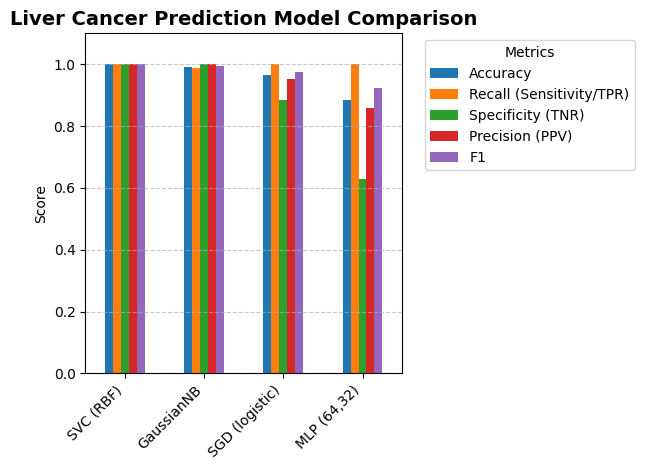

In [ ]:
# visualize model results for selected metrics
results = pd.DataFrame({
    "Accuracy": [1.000000, 0.991150, 0.964602, 0.884956],
    "Precision (PPV)": [1.000000, 1.000000, 0.951220, 0.857143],
    "Recall (Sensitivity/TPR)": [1.000000, 0.987179, 1.000000, 1.000000],
    "Specificity (TNR)": [1.000000, 1.000000, 0.885714, 0.628571],
    "F1": [1.000000, 0.993548, 0.975000, 0.923077],
}, index=["SVC (RBF)", "GaussianNB", "SGD (logistic)", "MLP (64,32)"])

# select metrics to visualize
metrics_to_plot = ["Accuracy", "Recall (Sensitivity/TPR)", "Specificity (TNR)", "Precision (PPV)", "F1"]
plot_data = results[metrics_to_plot]

# plot grouped bar chart 
plt.figure(figsize=(10,6))
plot_data.plot(kind="bar")
plt.title("Liver Cancer Prediction Model Comparison", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

- Above plot shows the visual representation of the main metrics (Accuracy, Recall, Specificity, Precision and F1). 
- SVC is best overall model and GuassianNB is nearly perfect.

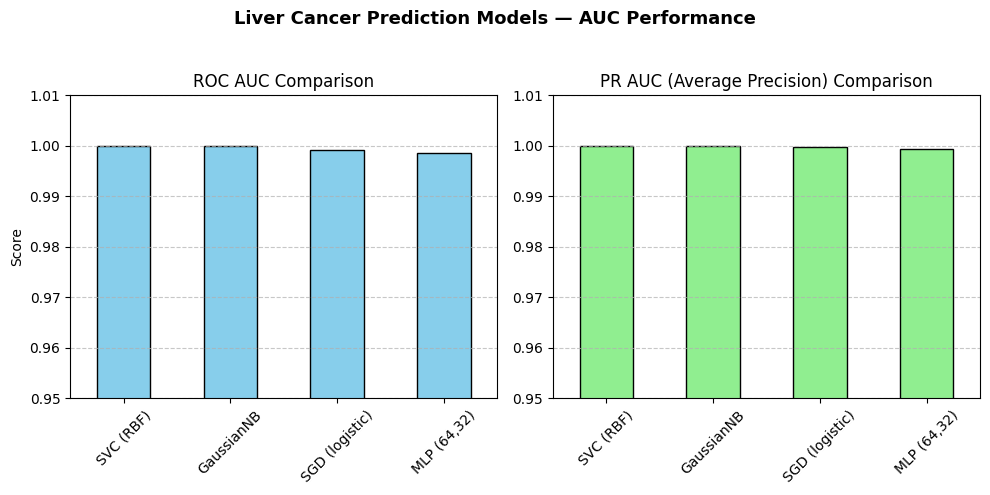

In [41]:
# Use your existing results DataFrame
results_auc = pd.DataFrame({
    "ROC AUC": [1.000000, 1.000000, 0.999267, 0.998535],
    "PR AUC (AP)": [1.000000, 1.000000, 0.999673, 0.999355]
}, index=["SVC (RBF)", "GaussianNB", "SGD (logistic)", "MLP (64,32)"])

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ROC AUC plot
results_auc["ROC AUC"].plot(kind="bar", ax=axes[0], color="skyblue", edgecolor="black")
axes[0].set_title("ROC AUC Comparison")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0.95, 1.01)
axes[0].grid(axis="y", linestyle="--", alpha=0.7)
axes[0].tick_params(axis='x', rotation=45)

# PR AUC plot
results_auc["PR AUC (AP)"].plot(kind="bar", ax=axes[1], color="lightgreen", edgecolor="black")
axes[1].set_title("PR AUC (Average Precision) Comparison")
axes[1].set_ylim(0.95, 1.01)
axes[1].grid(axis="y", linestyle="--", alpha=0.7)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("Liver Cancer Prediction Models — AUC Performance", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


**ROC AUC & PR AUC Comparison**
- All models have AUC > 0.99, which shows strong discrimination ability.
- SVC and GuassianNB both achieve perfect ROC and PR AUC of 1.0
- SGD and MLP also perform well but slightly below perfect.
- Visual shows all models can separate classes effectively.